In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LinearRegression
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('dark_background')
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

All libraries imported successfully!
PyTorch version: 2.11.0+cpu


In [55]:
# Load training and test data
train_df = pd.read_excel('train_data2.xlsx', engine='openpyxl')
test_df = pd.read_excel('test_data2.xlsx', engine='openpyxl')

# Separate features and target
X_train = train_df.drop('target', axis=1).values
y_train = train_df['target'].values
X_test = test_df.drop('target', axis=1).values
y_test = test_df['target'].values

print(f"Training data: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test data: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nClass distribution (train): {np.bincount(y_train)}")
print(f"Class distribution (test): {np.bincount(y_test)}")

# Z-score normalization (fit on train, apply to both)
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1  # Avoid division by zero

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print(f"Normalized {X_train.shape[1]} features")
print(f"Feature 0 - Mean: {X_train_scaled[:, 0].mean():.4f}, Std: {X_train_scaled[:, 0].std():.4f}")

Training data: 700 samples, 50 features
Test data: 300 samples, 50 features

Class distribution (train): [351 349]
Class distribution (test): [149 151]
Normalized 50 features
Feature 0 - Mean: 0.0000, Std: 1.0000


In [56]:
# Gaussian Naive Bayes
def estimate_probability_gaussian(x_value, data):
    """
    Estimate probability using Gaussian distribution.

    Returns:
    - Probability density at x_value
    """
    eps = 1e-9
    mean = np.mean(data)
    var = np.var(data) + eps
    coef = 1.0 / np.sqrt(2 * np.pi * var)
    exp_term = np.exp(-((x_value - mean) ** 2) / (2 * var))
    return coef * exp_term
def naive_bayes_fit_predict(X_train, y_train, X_test, method='gaussian', bandwidth=0.5):
    """
    Naive Bayes classifier with Gaussian or KDE likelihood estimation.

    Returns:
    - probas: Predicted probabilities for each class
    - priors: Prior probabilities
    - classes: Unique class labels
    """
    classes = np.unique(y_train)
    n_samples = X_test.shape[0]
    n_features = X_train.shape[1]
    n_classes = len(classes)

    class_data = {}
    priors = {}
    for c in classes:
        X_c = X_train[y_train == c]
        class_data[c] = X_c
        priors[c] = len(X_c) / len(y_train)

    log_probas = np.zeros((n_samples, n_classes))

    for i, x in enumerate(X_test):
        for j, c in enumerate(classes):
            log_posterior = np.log(priors[c] + 1e-9)

            for feature_idx in range(n_features):
                feature_value = x[feature_idx]
                feature_data = class_data[c][:, feature_idx]

                if method == 'gaussian':
                    likelihood = estimate_probability_gaussian(feature_value, feature_data)
                elif method == 'kde':
                    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
                    kde.fit(feature_data.reshape(-1, 1))
                    log_prob = kde.score_samples([[feature_value]])
                    likelihood = np.exp(log_prob[0])

                log_posterior += np.log(likelihood + 1e-9)

            log_probas[i, j] = log_posterior

    # Convert to probabilities (softmax-like normalization)
    max_log_proba = np.max(log_probas, axis=1, keepdims=True)
    probas = np.exp(log_probas - max_log_proba)
    # as we mentioned in lecture 11
    # we can subtract any constant (here we use the closest to zero to anchor) from all your log scores, and the final normalized probabilities will be exactly the same
    probas = probas / np.sum(probas, axis=1, keepdims=True)

    return probas, priors, classes


---

## Exercise 1: Naive Bayes with t-Distribution

Research the t-distribution and implement a version of `estimate_probability` that uses it instead of Gaussian.

**Hint:** Use `scipy.stats.t.pdf(x, df, loc, scale)` where:
- `df` = degrees of freedom (try 3-10)
- `loc` = mean of the data
- `scale` = std of the data

Then run Naive Bayes with your t-distribution function and compare with Gaussian.

In [57]:
def estimate_probability_t(x_value, data, df=5):
    """
    Estimate probability using t-distribution.

    Parameters:
    - x_value: The value to compute probability for
    - data: Training data for this feature in this class
    - df: Degrees of freedom (lower = heavier tails)

    Returns:
    - Probability density at x_value
    """
    loc = np.mean(data)
    scale = np.std(data)
    if scale == 0:
        scale = 1e-9
    
    prob_density = stats.t.pdf(x_value, df=df, loc=loc, scale=scale)
    
    return prob_density


def naive_bayes_t_distribution(X_train, y_train, X_test, df=5):
    """
    Naive Bayes with t-distribution likelihood.

    Complete this function to use estimate_probability_t instead of Gaussian.
    """
    
    n_smaples = X_test.shape[0]
    n_features = X_train.shape[1]
    classes = np.unique(y_train)
    n_classes = len(classes)
    
    classes_data = {}
    priors = {}
    for c in classes:
        X_c = X_train[y_train == c]
        classes_data[c] = X_c
        priors[c] = len(X_c) / len(y_train)
    
    log_probas = np.zeros((n_smaples, n_classes))
    for i, x in enumerate(X_test):
        for j, c in enumerate(classes):
            log_posterior = np.log(priors[c] + 1e-9)
            
            for feature_index in range(n_features):
                feature_value = x[feature_index]
                feature_data = classes_data[c][:,feature_index]
                
                likelihood = estimate_probability_t(feature_value, feature_data, df)
                
                log_posterior += np.log(likelihood + 1e-9)
            
            log_probas[i,j] = log_posterior
            
    max_log_prob = np.max(log_probas, axis=1, keepdims=True)
    probas = np.exp(log_probas - max_log_prob)
    
    probas = probas / np.sum(probas, axis=1, keepdims=True)
    
    return probas

In [58]:
# Test your implementation
probas_t = naive_bayes_t_distribution(X_train_scaled, y_train, X_test_scaled, df=5)
test_auc_t = roc_auc_score(y_test, probas_t[:, 1])
test_acc_t = accuracy_score(y_test, np.argmax(probas_t, axis=1))

probas_gauss, priors, classes = naive_bayes_fit_predict(
    X_train_scaled, y_train, X_test_scaled, method='gaussian'
)

test_auc_gauss = roc_auc_score(y_test, probas_gauss[:, 1])


print("T-DISTRIBUTION NAIVE BAYES")
print("="*50)
print(f"Test AUC: {test_auc_t:.4f}")
print(f"Test Accuracy: {test_acc_t:.4f}")
print(f"\nComparison with Gaussian AUC: {test_auc_gauss:.4f}")

T-DISTRIBUTION NAIVE BAYES
Test AUC: 1.0000
Test Accuracy: 1.0000

Comparison with Gaussian AUC: 1.0000


In [59]:
# Tests for Exercise 1

---

## Exercise 2: Robust Regression on Different Data

New synthetic dataset with:
- Different true relationship: `y = 0.5x + 10`
- 150 samples
- 15% outliers on the right side (high X values)

Then fit both gaussian and laplace assumptions.

**Note:** Don't worry about the data generation code

In [60]:
# Create new synthetic data
np.random.seed(123)
n_samples_ex2 = 150

# True relationship: y = 0.5x + 10
X_ex2 = np.random.uniform(0, 20, n_samples_ex2)
y_ex2_clean = 0.5 * X_ex2 + 10 + np.random.normal(0, 1, n_samples_ex2)

# Add 15% outliers on the RIGHT side, going UP
n_outliers_ex2 = int(0.15 * n_samples_ex2)
right_mask = X_ex2 > 15
right_indices = np.where(right_mask)[0]
outlier_idx_ex2 = np.random.choice(right_indices, min(n_outliers_ex2, len(right_indices)), replace=False)
y_ex2 = y_ex2_clean.copy()
y_ex2[outlier_idx_ex2] += np.random.uniform(8, 12, len(outlier_idx_ex2))  # All go UP

# gaussian assumptions
lr_mse = LinearRegression()
lr_mse.fit(X_ex2.reshape(-1, 1), y_ex2)

y_pred_mse = lr_mse.predict(X_ex2.reshape(-1, 1))

residuals_mse = y_ex2 - y_pred_mse
mse = np.mean(residuals_mse ** 2)

class HeteroscedasticModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.mean_layer = nn.Linear(1, 1)
        self.log_var_layer = nn.Linear(1, 1)

    def forward(self, x):
        mean = self.mean_layer(x)
        log_var = self.log_var_layer(x)
        return mean, log_var

# Train heteroscedastic model
X_torch = torch.tensor(X_ex2, dtype=torch.float32).reshape(-1, 1)
y_torch = torch.tensor(y_ex2, dtype=torch.float32).reshape(-1, 1)

hetero_model = HeteroscedasticModel()
optimizer_hetero = optim.Adam(hetero_model.parameters(), lr=0.01)

for epoch in range(2000):
    optimizer_hetero.zero_grad()
    mean_pred, log_var_pred = hetero_model(X_torch)

    # NLL
    var_pred = torch.exp(log_var_pred)
    nll_loss = 0.5 * log_var_pred + 0.5 * (y_torch - mean_pred) ** 2 / var_pred
    loss = nll_loss.mean()

    loss.backward()
    optimizer_hetero.step()

# Laplace assumptions
X_torch = torch.tensor(X_ex2, dtype=torch.float32).reshape(-1, 1)
y_torch = torch.tensor(y_ex2, dtype=torch.float32).reshape(-1, 1)

class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

# Model with L1 Loss (Laplace assumption)
model_laplace = LinearModel()
criterion_l1 = nn.L1Loss()  # MAE - corresponds to Laplace distribution
optimizer = optim.Adam(model_laplace.parameters(), lr=0.1)

# Training loop
losses = []
for epoch in range(1000):
    optimizer.zero_grad()
    predictions = model_laplace(X_torch)
    loss = criterion_l1(predictions, y_torch)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Get learned parameters
slope_laplace_ex2 = model_laplace.linear.weight.item()
intercept_laplace_ex2 = model_laplace.linear.bias.item()

# Print results
slope_mse_ex2 = lr_mse.coef_[0]
intercept_mse_ex2 = lr_mse.intercept_

print("="*50)
print("LINEAR REGRESSION WITH MSE")
print("="*50)
print(f"Fitted: y = {slope_mse_ex2:.3f}x + {intercept_mse_ex2:.3f}")
print(f"True:   y = 2.000x + 3.000")
print(f"\nMSE: {mse:.3f}")
print("="*50)

print("PYTORCH LINEAR REGRESSION WITH L1 LOSS (Laplace Assumption)")
print("="*50)
print(f"Fitted: y = {slope_laplace_ex2:.3f}x + {intercept_laplace_ex2:.3f}")
print(f"True:   y = 2.000x + 3.000")
print(f"\nFinal MAE: {losses[-1]:.3f}")

LINEAR REGRESSION WITH MSE
Fitted: y = 0.866x + 7.684
True:   y = 2.000x + 3.000

MSE: 8.880
PYTORCH LINEAR REGRESSION WITH L1 LOSS (Laplace Assumption)
Fitted: y = 0.555x + 9.601
True:   y = 2.000x + 3.000

Final MAE: 1.947


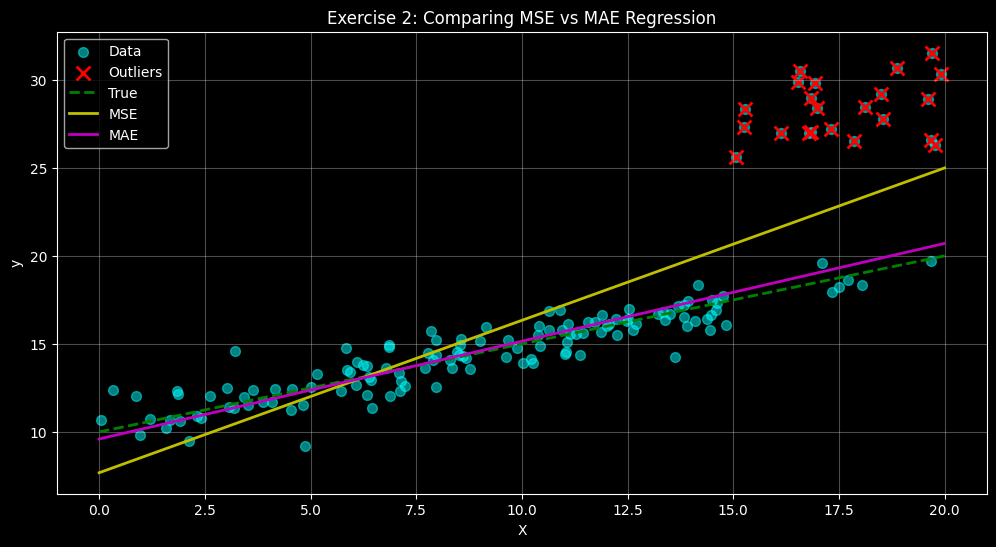

In [61]:
# Visualize your results
x_line_ex2 = np.linspace(0, 20, 100)

plt.figure(figsize=(12, 6))
plt.scatter(X_ex2, y_ex2, c='cyan', alpha=0.5, s=50, label='Data')
plt.scatter(X_ex2[outlier_idx_ex2], y_ex2[outlier_idx_ex2],
            c='red', s=100, marker='x', linewidth=2, label='Outliers')
plt.plot(x_line_ex2, 0.5 * x_line_ex2 + 10, 'g--', linewidth=2, label='True')
plt.plot(x_line_ex2, slope_mse_ex2 * x_line_ex2 + intercept_mse_ex2, 'y-', linewidth=2, label='MSE')
plt.plot(x_line_ex2, slope_laplace_ex2 * x_line_ex2 + intercept_laplace_ex2, 'm-', linewidth=2, label='MAE')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Exercise 2: Comparing MSE vs MAE Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [62]:
# Tests for Exercise 2